In [ ]:
## NO3 Trends - Shapley Values

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import accuracy_score, confusion_matrix
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.datasets import load_iris
#import xgboost as xgb 


In [1]:
import numpy as np

In [2]:
import pandas as pd

import sklearn
import shap

c:\Users\MPennino\miniconda3\envs\rfenvi\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load Dataset
# DATA = readRDS(paste0(strap_dir,'Data/Models/RF_bi_model_All_DATA_all_vars_','Trends_Conc_PWS_GW_05to20', '.rds'))
strap_dir = 'C:/Users/MPennino/OneDrive - Environmental Protection Agency (EPA)/Projects/StRAPs/StRAP4/SSWR.405.1_NO3_Trend_Causes/Data/Models/'
FILE_NAME = 'RF_bi_model_All_DATA_all_vars_Trends_Conc_PWS_GW_05to20.csv'
data = pd.read_csv(strap_dir+FILE_NAME)
data.head(3)

,DW_Trend,PctCrop2019Cat,PctForest2019Cat,FertCat,precip9120cat,tmean9120cat,WaterInputCat,BFICat,Precip_Minus_EVTCat,AgKffactCat,...,RockNCat,N_Surp_Change,All_Deficiencies_num,SystemSizePop,Administrative_Penalty_num,AltSource_yn,TreatmentTechniqueViols,MR_num,Nitrate_Treatment_yn,complete_N_mgmt_yn
0,1,0.000000,78.929400,0.000000,518.874944,9.035662,0.000000,32.980380,-4.883228,0.000000,...,25.642382,-163.180641,2,90,0,0,0,167,0,0
1,1,0.000000,78.929400,0.000000,518.874944,9.035662,0.000000,32.980380,-4.883228,0.000000,...,25.642382,-163.180641,0,130,0,0,0,103,0,0
2,-1,2.381455,0.000364,2.640785,161.975930,20.836734,0.094053,16.853464,-91.711311,0.008065,...,317.724395,396.772239,1,3554,0,0,0,115,0,1


In [4]:
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

In [5]:
import matplotlib.pyplot as plt

In [6]:
train,test=train_test_split(data,test_size=0.3,random_state=0,stratify=data['DW_Trend'])


In [7]:
train.head()

,DW_Trend,PctCrop2019Cat,PctForest2019Cat,FertCat,precip9120cat,tmean9120cat,WaterInputCat,BFICat,Precip_Minus_EVTCat,AgKffactCat,...,RockNCat,N_Surp_Change,All_Deficiencies_num,SystemSizePop,Administrative_Penalty_num,AltSource_yn,TreatmentTechniqueViols,MR_num,Nitrate_Treatment_yn,complete_N_mgmt_yn
288,1,2.750952,27.936667,4.419367,1374.024528,21.329746,0.008743,68.645476,27.446876,0.022476,...,89.768943,314.139740,2,1823,1,0,0,26,0,1
674,1,1.061569,8.329804,5.191971,1180.071340,13.388588,0.000017,35.595694,27.602902,0.071763,...,240.287939,-28.173612,3,54,0,0,2,12,0,1
565,1,42.271875,9.970625,35.127279,857.476184,7.185193,0.000219,48.904162,16.968692,0.147396,...,234.968842,1181.146069,0,1868,0,0,0,10,0,0
884,-1,0.300822,62.039452,7.114011,1206.037497,15.349095,0.000059,29.145699,27.266578,0.041803,...,105.707186,-24.019745,0,242,0,0,0,1,0,0
1570,-1,0.000000,80.588511,1.433191,1460.215660,5.629449,0.000035,44.405687,78.719921,0.026904,...,159.990532,-659.090797,7,40,0,0,0,14,0,0


In [8]:
# Convert categorical variables into dummy/indicator variables
train_processed = pd.get_dummies(train)
test_processed = pd.get_dummies(test)

# Filling Null Values
train_processed = train_processed.fillna(train_processed.mean())
test_processed = test_processed.fillna(test_processed.mean())

# Create X_train,Y_train,X_test
X_train = train_processed.drop(['DW_Trend'], axis=1)
Y_train = train_processed['DW_Trend']

X_test  = test_processed.drop(['DW_Trend'], axis=1)
Y_test  = test_processed['DW_Trend']

### Model Training

In [9]:
# Random Forest
random_forest = RandomForestClassifier(n_estimators=100)
random_forest.fit(X_train, Y_train)
random_forest_preds = random_forest.predict(X_test)
print('The accuracy of the Random Forests model is :\t',metrics.accuracy_score(random_forest_preds,Y_test))

The accuracy of the Random Forests model is :	 0.7608247422680412


In [10]:
# Create Tree Explainer object that can calculate shap values
explainer = shap.TreeExplainer(random_forest)

In [11]:
#Let's choose some instances from the test dataset to understand to the classifier makes predictions for them.
test.loc[[50]]

,DW_Trend,PctCrop2019Cat,PctForest2019Cat,FertCat,precip9120cat,tmean9120cat,WaterInputCat,BFICat,Precip_Minus_EVTCat,AgKffactCat,...,RockNCat,N_Surp_Change,All_Deficiencies_num,SystemSizePop,Administrative_Penalty_num,AltSource_yn,TreatmentTechniqueViols,MR_num,Nitrate_Treatment_yn,complete_N_mgmt_yn
50,-1,20.714324,15.570541,85.262797,948.685849,14.556658,0.007014,35.489232,18.662268,0.085251,...,116.912878,-1072.865861,0,188,0,0,0,20,0,1


In [12]:
# Calculate Shap values
#choosen_instance = X_test.loc[[50]]
#shap_values = explainer.shap_values(choosen_instance)
shap_values = explainer(X_test) # 20 sec

#shap.initjs()
#shap.force_plot(explainer.expected_value[1], shap_values[1], choosen_instance)

In [47]:
X_test.shape, X_train.shape

((485, 28), (1129, 28))

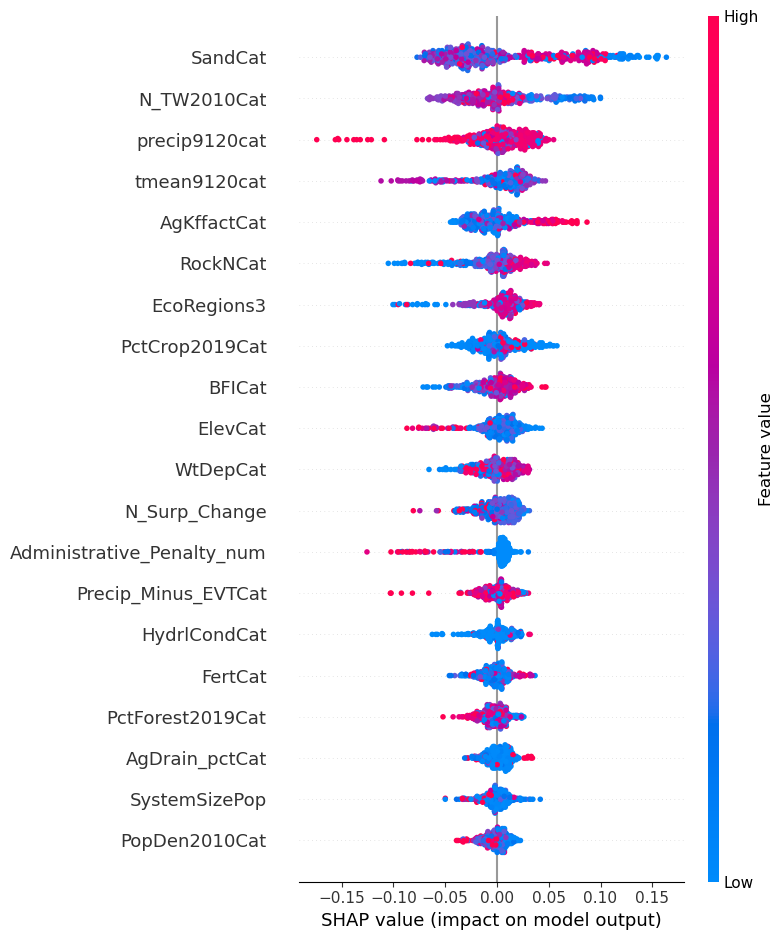

In [14]:
shap.summary_plot(shap_values[:,:,1], X_test)

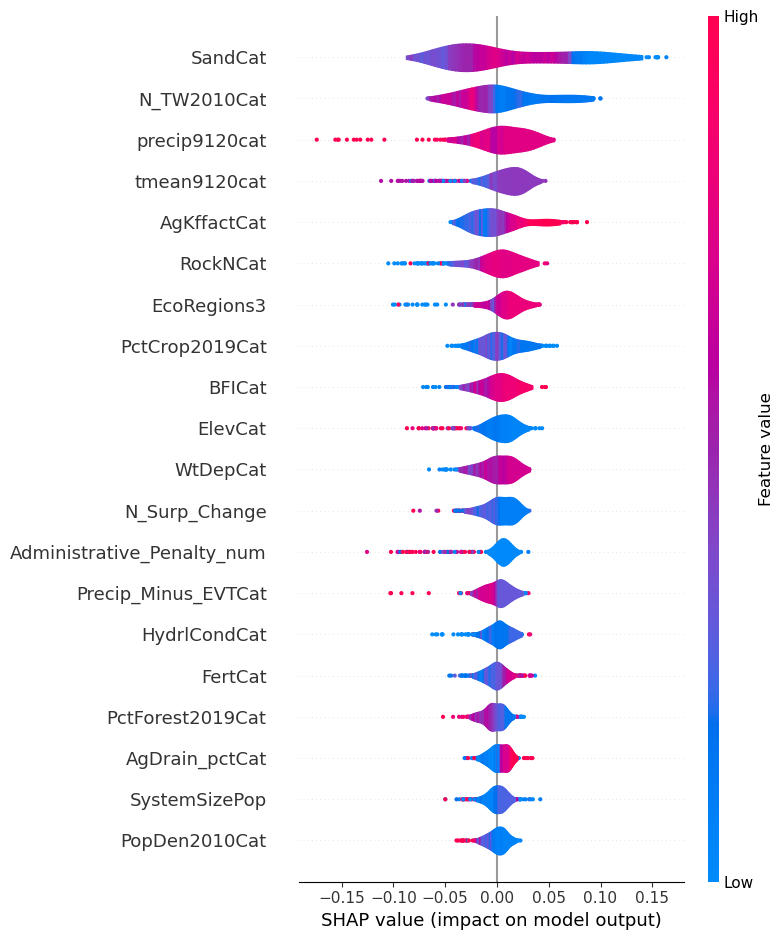

In [15]:
shap.summary_plot(shap_values[:,:,1], plot_type='violin')


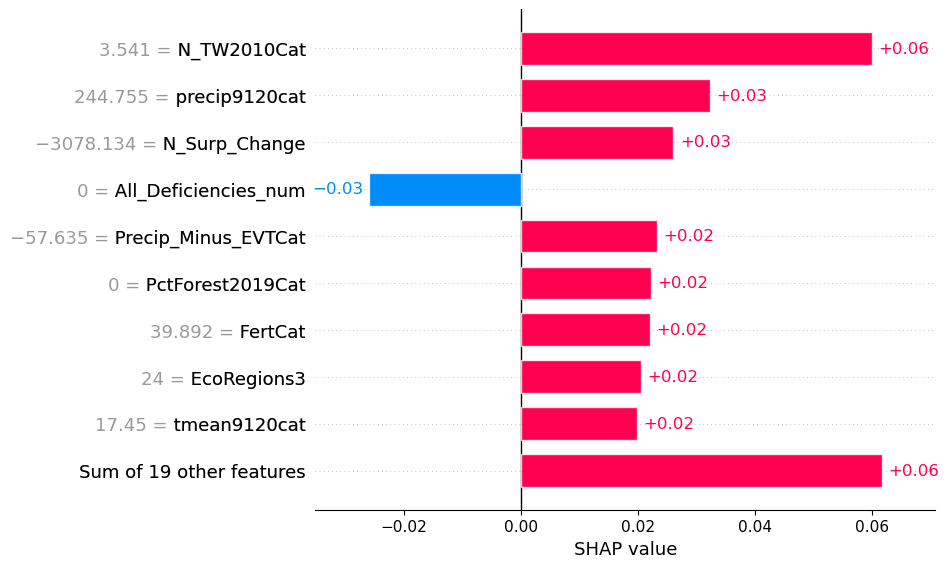

In [16]:
# Local Bar plot
shap.plots.bar(shap_values[:,:,1][4])

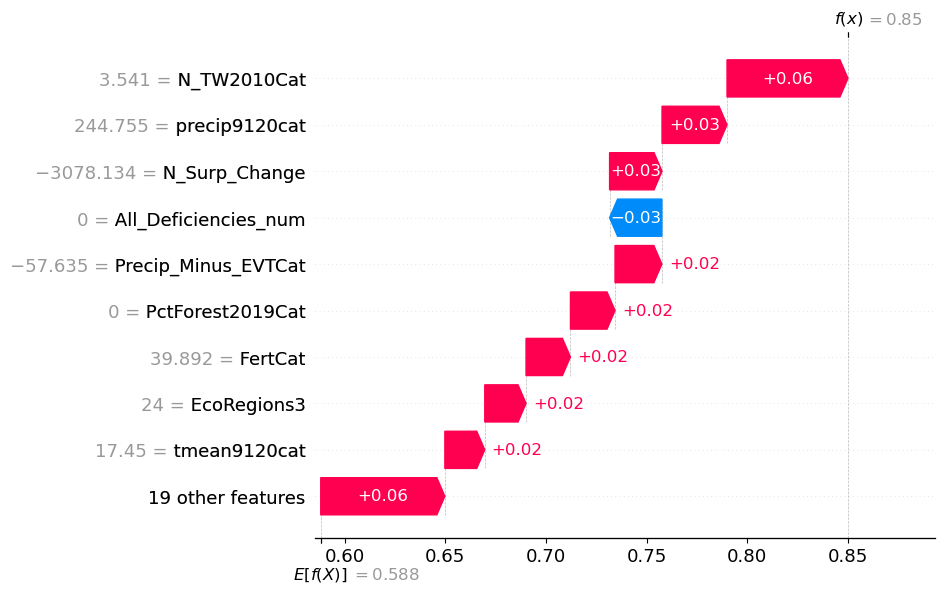

In [18]:
# Local Waterfall plot
shap.plots.waterfall(shap_values[:,:,1][4])